# Movement 2023-01 수도권 탐색

**목적**: 2023년 1월 수도권 KT Movement 데이터(약 1.28억 행)를 셀별로 훑어보면서, 학회 일정 동안 어떤 추가 분석을 할지 감을 잡는다.

**규모**

- 31일 × 24시간 × 1,155 × 1,155 OD (sparse)
- 약 1.28억 rows, parquet 1.77 GB

**다룰 질문**

1. 어디↔어디 이동이 많은가? (top OD pairs)
2. 거리 분포는 어떤가? (avg_dist)
3. 시간대별로 패턴이 어떻게 다른가? (출근/점심/퇴근/심야)
4. 목적·연령·행정동별 차이는?

**데이터 한계**

- KT 시그널링 기반 → 보정된 인구수(total). 실제 통행량이 아니라 KT가 추정한 통행량.
- avg_dist 단위는 규격서에 모순이 있으니, 절대값보다 상대 비교 위주로 본다.
- 같은 행정동 내 이동(o==d)이 다수 포함되어 있어, 필요할 때 분리해서 본다.

In [1]:
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATA_DIR = Path('../data/raw')
MAPPING_DIR = Path('../data/mapping')
OUT_DIR = Path('../outputs/movement_2023_01_exploration')
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 100

## 1. 데이터 로드

Movement 본체(parquet)와 행정동 매핑(이름표)을 읽는다. polars로 한 번에 메모리에 올린다 — 1.77GB 정도라 로컬에서도 무리 없음.

In [2]:
df = pl.read_parquet(DATA_DIR / 'movement_sudogwon_202301.parquet')
mapping = pl.read_parquet(MAPPING_DIR / 'sudogwon_admdong.parquet')

print(f"Movement rows : {len(df):,}")
print(f"Mapping rows  : {len(mapping):,}")
print()
print('--- schema ---')
print(df.schema)
df.head()

Movement rows : 127,985,007
Mapping rows  : 1,314

--- schema ---
Schema({'date': Int32, 'hour': Int8, 'o_admdong_cd': String, 'o_admdong_nm': String, 'd_admdong_cd': String, 'd_admdong_nm': String, 'age_10': Int8, 'purpose': Int8, 'total': Float64, 'avg_dist': Float64, 'avg_time': Float64})


date,hour,o_admdong_cd,o_admdong_nm,d_admdong_cd,d_admdong_nm,age_10,purpose,total,avg_dist,avg_time
i32,i8,str,str,str,str,i8,i8,f64,f64,f64
20230101,0,"""11110515""","""청운효자동""","""11110515""","""청운효자동""",10,3,2.81,400.0,0.0
20230101,0,"""11110515""","""청운효자동""","""11110515""","""청운효자동""",20,3,2.36,400.0,430.0
20230101,0,"""11110515""","""청운효자동""","""11110515""","""청운효자동""",20,7,4.16,400.0,19.519231
20230101,0,"""11110515""","""청운효자동""","""11110515""","""청운효자동""",30,3,2.27,400.0,0.0
20230101,0,"""11110515""","""청운효자동""","""11110515""","""청운효자동""",30,7,11.42,270.140105,13.57268


## 2. 기본 통계

- 총 이동 인구 합계
- 일별 시계열 (평일/주말 차이 보기)
- 시간대별 분포 (24시간)
- 연령대별 합계
- 목적별 합계

Total movements (sum of `total`): 923,435,300



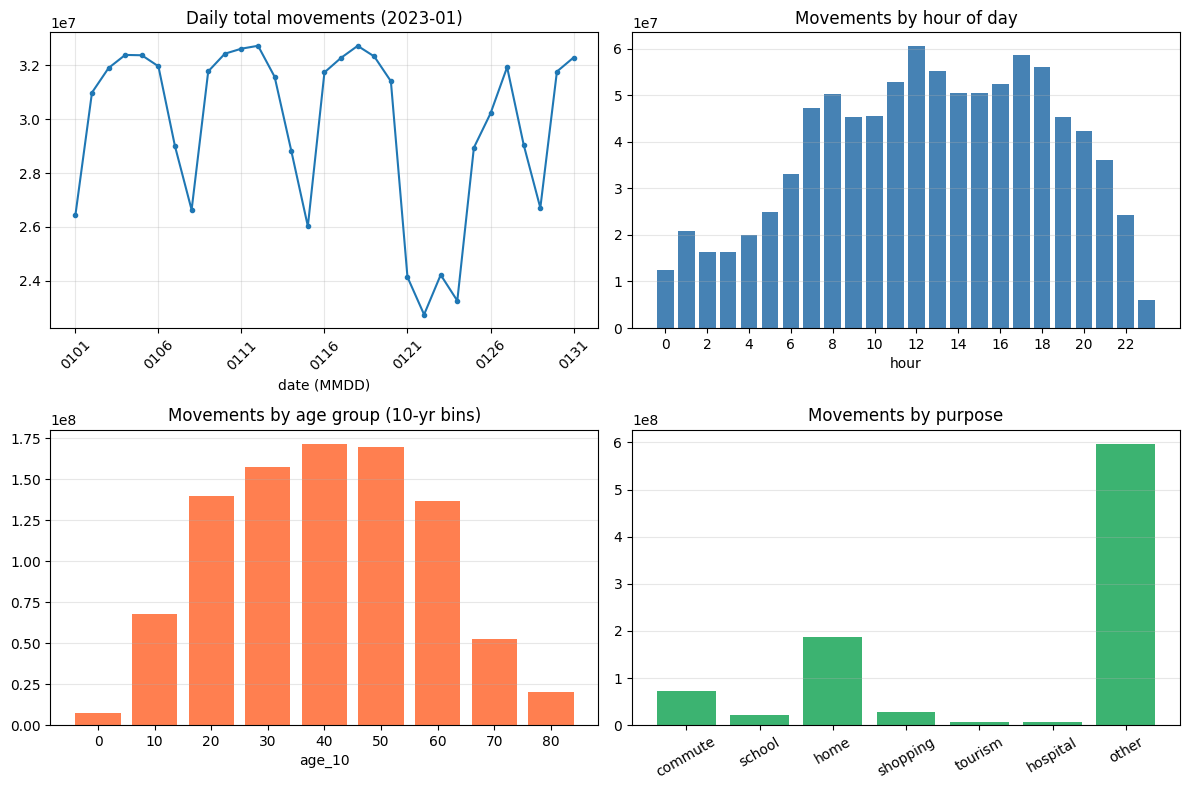

In [3]:
total_sum = df.select(pl.col('total').sum()).item()
print(f"Total movements (sum of `total`): {total_sum:,.0f}")
print()

# Daily series
daily = (
    df.group_by('date')
      .agg(pl.col('total').sum().alias('total'))
      .sort('date')
)

# Hour distribution
hourly = (
    df.group_by('hour')
      .agg(pl.col('total').sum().alias('total'))
      .sort('hour')
)

# Age
by_age = (
    df.group_by('age_10')
      .agg(pl.col('total').sum().alias('total'))
      .sort('age_10')
)

# Purpose
PURPOSE_LABELS = {1: 'commute', 2: 'school', 3: 'home', 4: 'shopping',
                  5: 'tourism', 6: 'hospital', 7: 'other'}
by_purpose = (
    df.group_by('purpose')
      .agg(pl.col('total').sum().alias('total'))
      .sort('purpose')
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Daily
dates = daily['date'].to_numpy()
axes[0, 0].plot(range(len(dates)), daily['total'].to_numpy(), marker='o', ms=3)
axes[0, 0].set_xticks(range(0, len(dates), 5))
axes[0, 0].set_xticklabels([str(d)[-4:] for d in dates[::5]], rotation=45)
axes[0, 0].set_title('Daily total movements (2023-01)')
axes[0, 0].set_xlabel('date (MMDD)')
axes[0, 0].grid(alpha=0.3)

# Hourly
axes[0, 1].bar(hourly['hour'].to_numpy(), hourly['total'].to_numpy(),
               color='steelblue')
axes[0, 1].set_title('Movements by hour of day')
axes[0, 1].set_xlabel('hour')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].grid(axis='y', alpha=0.3)

# Age
axes[1, 0].bar([str(a) for a in by_age['age_10'].to_numpy()],
               by_age['total'].to_numpy(), color='coral')
axes[1, 0].set_title('Movements by age group (10-yr bins)')
axes[1, 0].set_xlabel('age_10')
axes[1, 0].grid(axis='y', alpha=0.3)

# Purpose
labels = [PURPOSE_LABELS.get(p, str(p)) for p in by_purpose['purpose'].to_numpy()]
axes[1, 1].bar(labels, by_purpose['total'].to_numpy(), color='mediumseagreen')
axes[1, 1].set_title('Movements by purpose')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Top OD pairs — 어디↔어디 이동이 많은가

같은 행정동 내 이동(o == d)과 다른 행정동으로의 이동(o != d)을 분리해서 본다. 같은 동 안 이동(자기 자신)이 보통 압도적으로 많기 때문에 섞어 보면 "외부로 가는 통행" 패턴이 묻힌다.

--- Top 20 same-dong (o == d) ---
shape: (20, 5)
┌──────────────┬──────────────┬──────────────┬──────────────┬──────────┐
│ o_admdong_cd ┆ d_admdong_cd ┆ o_admdong_nm ┆ d_admdong_nm ┆ total    │
│ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---      │
│ str          ┆ str          ┆ str          ┆ str          ┆ f64      │
╞══════════════╪══════════════╪══════════════╪══════════════╪══════════╡
│ 11560540     ┆ 11560540     ┆ 여의동       ┆ 여의동       ┆ 3.5594e6 │
│ 41360253     ┆ 41360253     ┆ 진접읍       ┆ 진접읍       ┆ 3.2675e6 │
│ 11680640     ┆ 11680640     ┆ 역삼1동      ┆ 역삼1동      ┆ 2.9218e6 │
│ 41360256     ┆ 41360256     ┆ 화도읍       ┆ 화도읍       ┆ 2.9096e6 │
│ 41360570     ┆ 41360570     ┆ 별내동       ┆ 별내동       ┆ 2.6114e6 │
│ …            ┆ …            ┆ …            ┆ …            ┆ …        │
│ 41115730     ┆ 41115730     ┆ 인계동       ┆ 인계동       ┆ 1.5243e6 │
│ 11710642     ┆ 11710642     ┆ 문정2동      ┆ 문정2동      ┆ 1.5096e6 │
│ 41465560     ┆ 41465560     ┆ 동천동       ┆ 

/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2743117351.py:38: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2743117351.py:38: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2743117351.py:38: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2743117351.py:38: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2743117351.py:38: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipyke

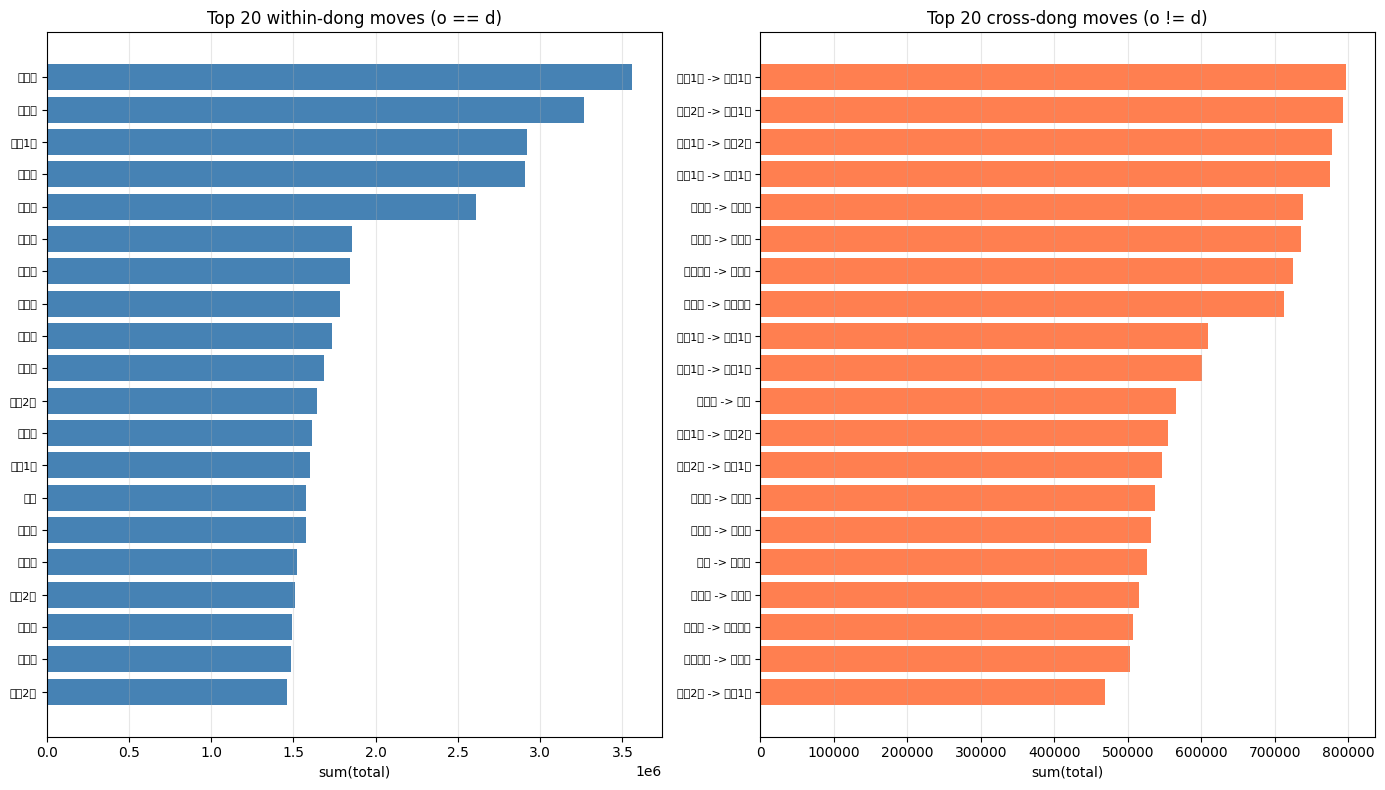

In [4]:
od_grouped = (
    df.group_by(['o_admdong_cd', 'd_admdong_cd', 'o_admdong_nm', 'd_admdong_nm'])
      .agg(pl.col('total').sum().alias('total'))
)

same = (od_grouped.filter(pl.col('o_admdong_cd') == pl.col('d_admdong_cd'))
        .sort('total', descending=True).head(20))
diff = (od_grouped.filter(pl.col('o_admdong_cd') != pl.col('d_admdong_cd'))
        .sort('total', descending=True).head(20))

print('--- Top 20 same-dong (o == d) ---')
print(same)
print()
print('--- Top 20 cross-dong (o != d) ---')
print(diff)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

same_labels = [f"{nm}" for nm in same['o_admdong_nm'].to_numpy()]
axes[0].barh(range(len(same)), same['total'].to_numpy(), color='steelblue')
axes[0].set_yticks(range(len(same)))
axes[0].set_yticklabels(same_labels, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 within-dong moves (o == d)')
axes[0].set_xlabel('sum(total)')
axes[0].grid(axis='x', alpha=0.3)

diff_labels = [f"{o} -> {d}" for o, d in zip(diff['o_admdong_nm'].to_numpy(),
                                             diff['d_admdong_nm'].to_numpy())]
axes[1].barh(range(len(diff)), diff['total'].to_numpy(), color='coral')
axes[1].set_yticks(range(len(diff)))
axes[1].set_yticklabels(diff_labels, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 cross-dong moves (o != d)')
axes[1].set_xlabel('sum(total)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 시간대별 OD 패턴

대표 시간 4개(08시 출근, 12시 점심, 18시 퇴근, 03시 심야)를 골라, 각 시간대 cross-dong top 10을 비교한다. 출근/퇴근 시간엔 업무지구로/주거지로 향하는 방향성이, 심야엔 다른 패턴이 보일지.

/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/1996535954.py:27: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/1996535954.py:27: UserWarning: Glyph 44263 (\N{HANGUL SYLLABLE GOD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/1996535954.py:27: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/1996535954.py:27: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/1996535954.py:27: UserWarning: Glyph 50773 (\N{HANGUL SYLLABLE WANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ip

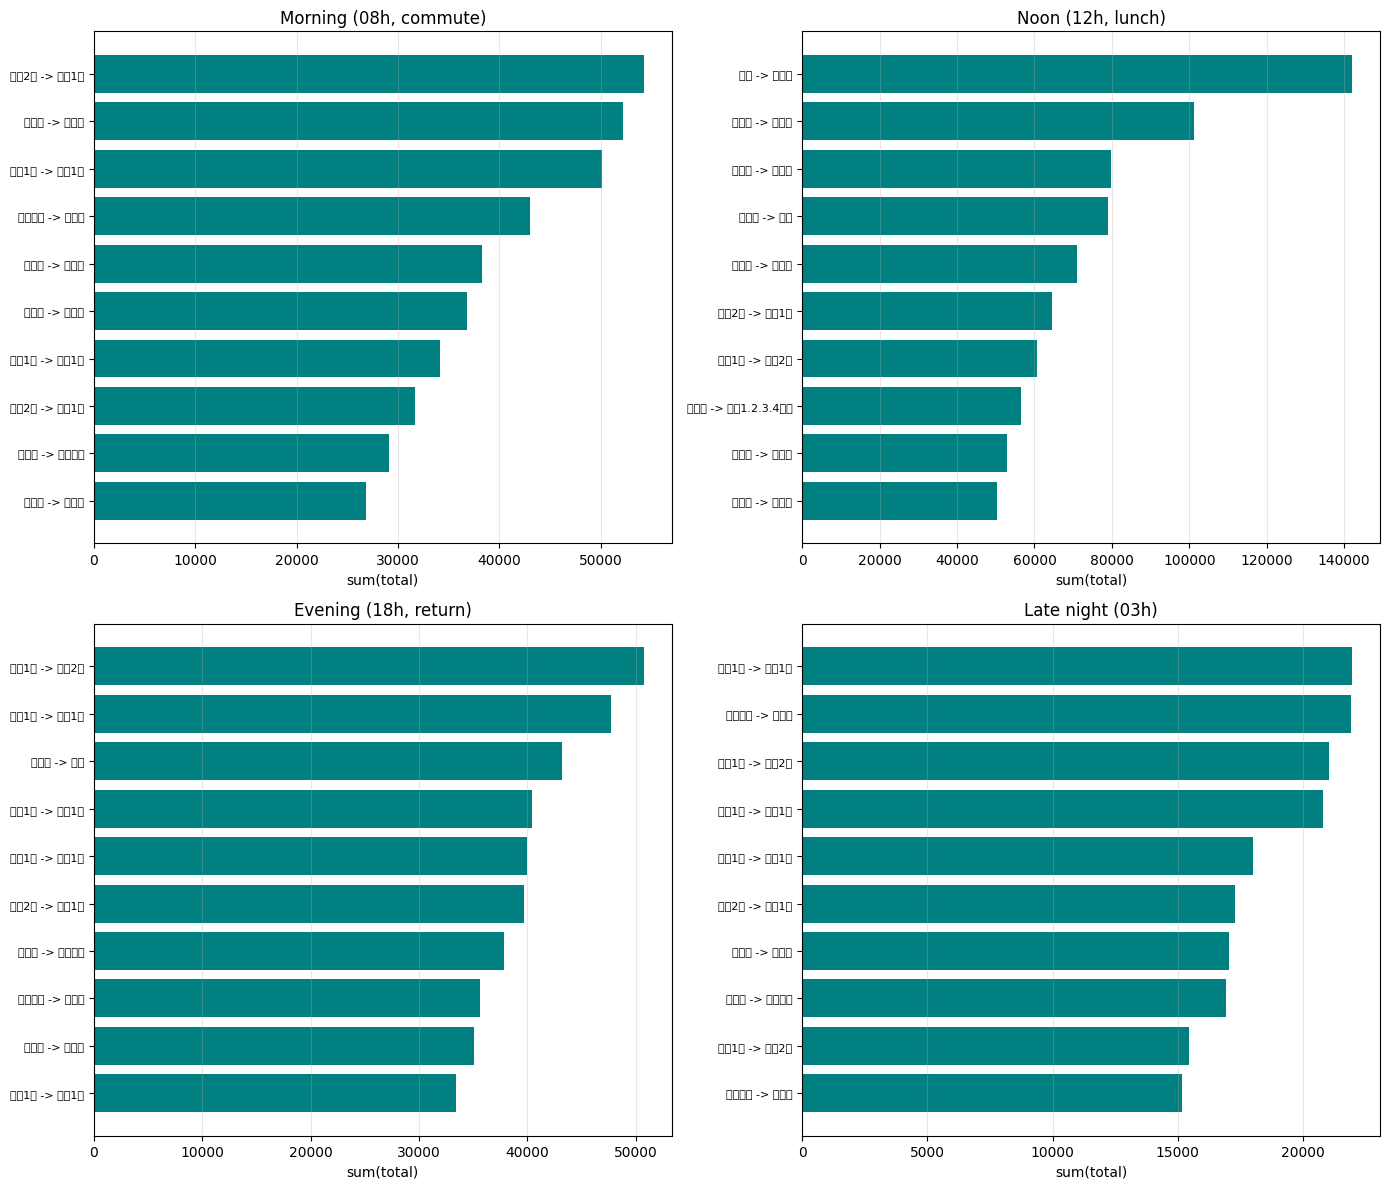

In [5]:
TIMESLOTS = [(8, 'Morning (08h, commute)'),
             (12, 'Noon (12h, lunch)'),
             (18, 'Evening (18h, return)'),
             (3, 'Late night (03h)')]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (hr, title) in zip(axes.ravel(), TIMESLOTS):
    top = (
        df.filter((pl.col('hour') == hr) &
                  (pl.col('o_admdong_cd') != pl.col('d_admdong_cd')))
          .group_by(['o_admdong_nm', 'd_admdong_nm'])
          .agg(pl.col('total').sum().alias('total'))
          .sort('total', descending=True)
          .head(10)
    )
    labels = [f"{o} -> {d}" for o, d in zip(top['o_admdong_nm'].to_numpy(),
                                            top['d_admdong_nm'].to_numpy())]
    ax.barh(range(len(top)), top['total'].to_numpy(), color='teal')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('sum(total)')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 이동 거리 분포

`avg_dist`의 단위는 KT 규격서에서 모순이 있어 절대값으로 해석하기 어렵다. 일단 분포 형태만 본다.

- total을 가중치로 사용 (각 row는 1건이 아니라 보정된 인구수임)
- 같은 동 내(o==d) vs 다른 동(o!=d) 분리
- x축 로그 스케일 (장단거리 차이가 크기 때문)

 within-dong  weighted mean =  642.940
             q25 =  297.173
             q50 =  463.159
             q75 =  813.757
             q90 = 1310.601
             q99 = 2598.439

  cross-dong  weighted mean = 7290.094
             q25 = 1152.948
             q50 = 3145.004
             q75 = 8978.715
             q90 = 19700.000
             q99 = 50900.000



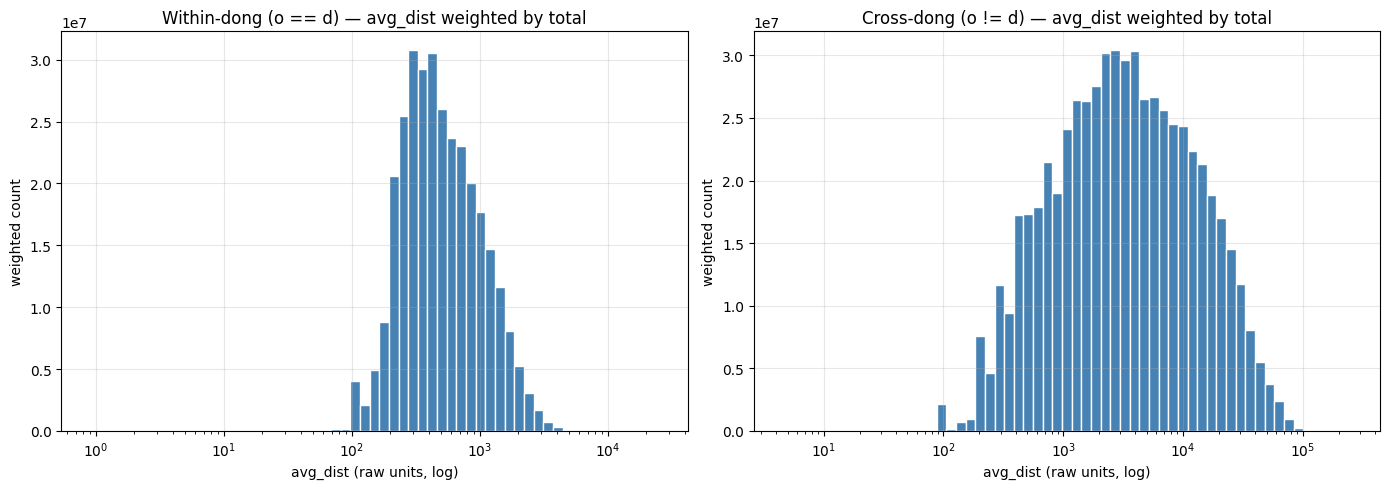

In [6]:
same_dist = df.filter(pl.col('o_admdong_cd') == pl.col('d_admdong_cd'))
diff_dist = df.filter(pl.col('o_admdong_cd') != pl.col('d_admdong_cd'))

def weighted_quantiles(ddf, qs=(0.25, 0.5, 0.75, 0.9, 0.99)):
    d = ddf.select(['avg_dist', 'total']).drop_nulls().filter(pl.col('avg_dist') > 0)
    arr = d['avg_dist'].to_numpy()
    w = d['total'].to_numpy()
    order = np.argsort(arr)
    arr, w = arr[order], w[order]
    cum = np.cumsum(w)
    total = cum[-1]
    out = {}
    for q in qs:
        idx = np.searchsorted(cum, q * total)
        idx = min(idx, len(arr) - 1)
        out[q] = float(arr[idx])
    mean = float(np.sum(arr * w) / total)
    return mean, out

for name, ddf in [('within-dong', same_dist), ('cross-dong', diff_dist)]:
    m, q = weighted_quantiles(ddf)
    print(f"{name:>12}  weighted mean = {m:8.3f}")
    for k, v in q.items():
        print(f"             q{int(k*100):02d} = {v:8.3f}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ddf, title in [(axes[0], same_dist, 'Within-dong (o == d)'),
                       (axes[1], diff_dist, 'Cross-dong (o != d)')]:
    d = ddf.select(['avg_dist', 'total']).drop_nulls().filter(pl.col('avg_dist') > 0)
    vals = d['avg_dist'].to_numpy()
    wts = d['total'].to_numpy()
    bins = np.logspace(np.log10(max(vals.min(), 1e-3)),
                       np.log10(vals.max()), 60)
    ax.hist(vals, bins=bins, weights=wts, color='steelblue', edgecolor='white')
    ax.set_xscale('log')
    ax.set_title(f'{title} — avg_dist weighted by total')
    ax.set_xlabel('avg_dist (raw units, log)')
    ax.set_ylabel('weighted count')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 시간대별 평균 이동 거리

출퇴근 시간엔 멀리 가고, 점심엔 가까이 갈 거란 가설을 본다. 가중평균(total 가중)으로 hour별 평균 거리를 계산.

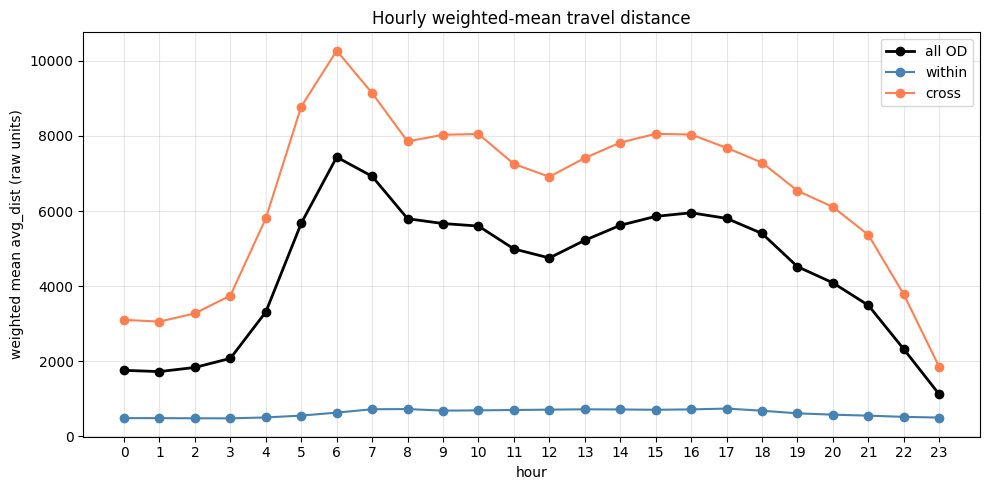

In [7]:
hourly_dist = (
    df.filter(pl.col('avg_dist').is_not_null() & (pl.col('avg_dist') > 0))
      .group_by('hour')
      .agg([
          (pl.col('avg_dist') * pl.col('total')).sum().alias('num'),
          pl.col('total').sum().alias('den'),
      ])
      .with_columns((pl.col('num') / pl.col('den')).alias('w_avg_dist'))
      .sort('hour')
)

# Same but split by within/cross
hourly_dist_split = (
    df.filter(pl.col('avg_dist').is_not_null() & (pl.col('avg_dist') > 0))
      .with_columns(
          pl.when(pl.col('o_admdong_cd') == pl.col('d_admdong_cd'))
          .then(pl.lit('within')).otherwise(pl.lit('cross')).alias('kind')
      )
      .group_by(['hour', 'kind'])
      .agg([
          (pl.col('avg_dist') * pl.col('total')).sum().alias('num'),
          pl.col('total').sum().alias('den'),
      ])
      .with_columns((pl.col('num') / pl.col('den')).alias('w_avg_dist'))
      .sort(['kind', 'hour'])
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_dist['hour'].to_numpy(),
        hourly_dist['w_avg_dist'].to_numpy(),
        marker='o', label='all OD', color='black', lw=2)
for kind, color in [('within', 'steelblue'), ('cross', 'coral')]:
    sub = hourly_dist_split.filter(pl.col('kind') == kind)
    ax.plot(sub['hour'].to_numpy(), sub['w_avg_dist'].to_numpy(),
            marker='o', label=kind, color=color)
ax.set_xticks(range(0, 24))
ax.set_xlabel('hour')
ax.set_ylabel('weighted mean avg_dist (raw units)')
ax.set_title('Hourly weighted-mean travel distance')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 7. 목적별 패턴

보통 KT Movement에서 `purpose=7 (other)`이 압도적으로 많고 `purpose=3 (home / return)`이 그 다음으로 흔하다. 나머지는 비중이 적은 편. 시간대별로 어떤 목적이 언제 많은지 히트맵으로 본다.

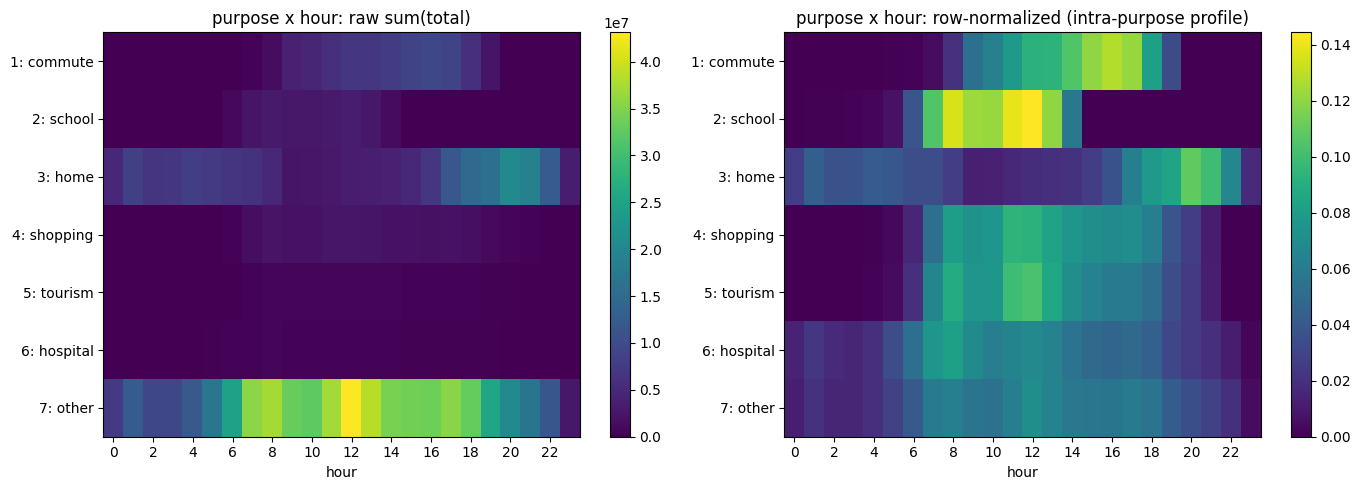

In [8]:
ph = (
    df.group_by(['purpose', 'hour'])
      .agg(pl.col('total').sum().alias('total'))
      .sort(['purpose', 'hour'])
)

purposes = sorted(ph['purpose'].unique().to_list())
hours = list(range(24))
mat = np.zeros((len(purposes), len(hours)))
for row in ph.iter_rows(named=True):
    i = purposes.index(row['purpose'])
    j = row['hour']
    mat[i, j] = row['total']

# Row-normalize so each purpose has its own intensity profile across hours
row_sum = mat.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
mat_norm = mat / row_sum

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ylabels = [f"{p}: {PURPOSE_LABELS.get(p, '?')}" for p in purposes]

im0 = axes[0].imshow(mat, aspect='auto', cmap='viridis')
axes[0].set_yticks(range(len(purposes)))
axes[0].set_yticklabels(ylabels)
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xlabel('hour')
axes[0].set_title('purpose x hour: raw sum(total)')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mat_norm, aspect='auto', cmap='viridis')
axes[1].set_yticks(range(len(purposes)))
axes[1].set_yticklabels(ylabels)
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xlabel('hour')
axes[1].set_title('purpose x hour: row-normalized (intra-purpose profile)')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## 8. 연령대별 패턴

- 연령대(10세 단위)별 평균 이동거리 비교 (가중평균)
- 연령대 × 시간대 히트맵 (행별 정규화 — 즉, 각 연령이 "하루 중 언제" 움직이는지)

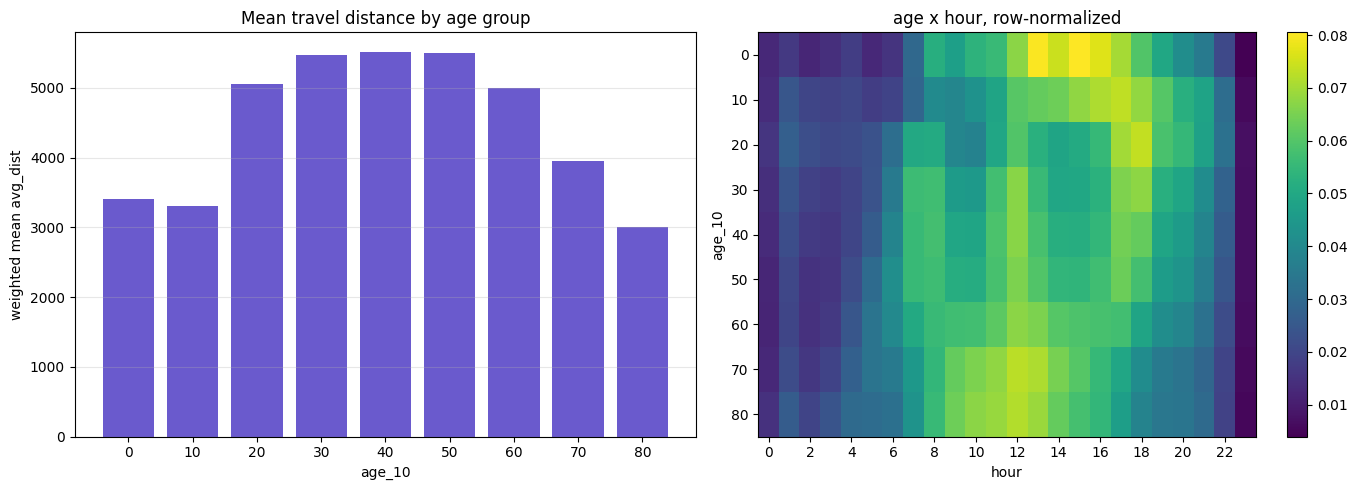

In [9]:
# Age x weighted mean distance
age_dist = (
    df.filter(pl.col('avg_dist').is_not_null() & (pl.col('avg_dist') > 0))
      .group_by('age_10')
      .agg([
          (pl.col('avg_dist') * pl.col('total')).sum().alias('num'),
          pl.col('total').sum().alias('den'),
      ])
      .with_columns((pl.col('num') / pl.col('den')).alias('w_avg_dist'))
      .sort('age_10')
)

# Age x hour matrix
ah = (
    df.group_by(['age_10', 'hour'])
      .agg(pl.col('total').sum().alias('total'))
      .sort(['age_10', 'hour'])
)
ages = sorted(ah['age_10'].unique().to_list())
mat_ah = np.zeros((len(ages), 24))
for row in ah.iter_rows(named=True):
    mat_ah[ages.index(row['age_10']), row['hour']] = row['total']
row_sum = mat_ah.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
mat_ah_norm = mat_ah / row_sum

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([str(a) for a in age_dist['age_10'].to_numpy()],
            age_dist['w_avg_dist'].to_numpy(), color='slateblue')
axes[0].set_xlabel('age_10')
axes[0].set_ylabel('weighted mean avg_dist')
axes[0].set_title('Mean travel distance by age group')
axes[0].grid(axis='y', alpha=0.3)

im = axes[1].imshow(mat_ah_norm, aspect='auto', cmap='viridis')
axes[1].set_yticks(range(len(ages)))
axes[1].set_yticklabels([str(a) for a in ages])
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xlabel('hour')
axes[1].set_ylabel('age_10')
axes[1].set_title('age x hour, row-normalized')
fig.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## 9. 행정동별 유입/유출 균형

각 행정동에 대해:

- **inflow** = 도착지(d)가 그 동인 통행 합 (자기→자기 제외)
- **outflow** = 출발지(o)가 그 동인 통행 합 (자기→자기 제외)
- **net** = inflow − outflow

net이 큰 양수면 "활동지"(들어오는 사람이 많은 곳 — 업무·상업지구), 큰 음수면 "거주지"(나가는 사람이 많은 곳).

--- Top 20 activity hubs (net > 0) ---
shape: (20, 4)
┌────────────┬───────────┬───────────┬───────────┐
│ admdong_nm ┆ inflow    ┆ outflow   ┆ net       │
│ ---        ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╪═══════════╡
│ 공항동     ┆ 1.0429e6  ┆ 796803.14 ┆ 246081.77 │
│ 역삼1동    ┆ 4.4483e6  ┆ 4.2345e6  ┆ 213859.07 │
│ 서교동     ┆ 2.1924e6  ┆ 1.9981e6  ┆ 194286.26 │
│ 수서동     ┆ 587277.74 ┆ 395124.1  ┆ 192153.64 │
│ 여의동     ┆ 4.2184e6  ┆ 4.0466e6  ┆ 171803.97 │
│ …          ┆ …         ┆ …         ┆ …         │
│ 대치4동    ┆ 1.3163e6  ┆ 1.2409e6  ┆ 75388.46  │
│ 남영동     ┆ 727568.93 ┆ 655389.58 ┆ 72179.35  │
│ 초지동     ┆ 2.8560e6  ┆ 2.7899e6  ┆ 66127.97  │
│ 삼성1동    ┆ 1.7339e6  ┆ 1.6683e6  ┆ 65620.2   │
│ 영등포동   ┆ 2.0592e6  ┆ 1.9970e6  ┆ 62185.45  │
└────────────┴───────────┴───────────┴───────────┘

--- Top 20 residential (net < 0) ---
shape: (20, 4)
┌────────────┬───────────┬───────────┬────────────┐
│ adm

/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2755493509.py:51: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2755493509.py:51: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2755493509.py:51: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2755493509.py:51: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_56367/2755493509.py:51: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ip

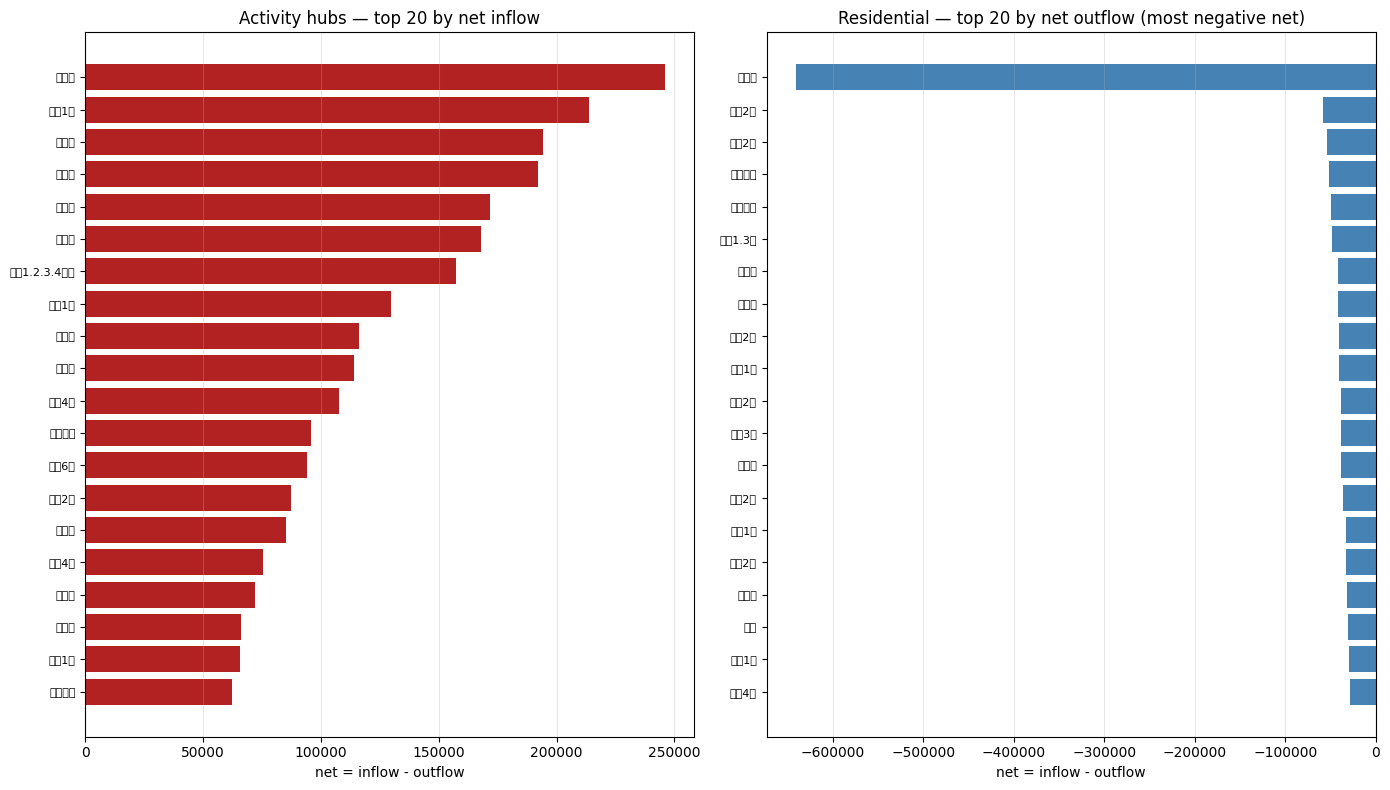

In [10]:
cross = df.filter(pl.col('o_admdong_cd') != pl.col('d_admdong_cd'))

inflow = (
    cross.group_by(['d_admdong_cd', 'd_admdong_nm'])
         .agg(pl.col('total').sum().alias('inflow'))
         .rename({'d_admdong_cd': 'admdong_cd', 'd_admdong_nm': 'admdong_nm'})
)
outflow = (
    cross.group_by(['o_admdong_cd', 'o_admdong_nm'])
         .agg(pl.col('total').sum().alias('outflow'))
         .rename({'o_admdong_cd': 'admdong_cd', 'o_admdong_nm': 'admdong_nm'})
)
flow = (
    inflow.join(outflow, on=['admdong_cd', 'admdong_nm'], how='full', coalesce=True)
          .with_columns([
              pl.col('inflow').fill_null(0),
              pl.col('outflow').fill_null(0),
          ])
          .with_columns((pl.col('inflow') - pl.col('outflow')).alias('net'))
)

top_activity = flow.sort('net', descending=True).head(20)
top_residential = flow.sort('net', descending=False).head(20)

print('--- Top 20 activity hubs (net > 0) ---')
print(top_activity.select(['admdong_nm', 'inflow', 'outflow', 'net']))
print()
print('--- Top 20 residential (net < 0) ---')
print(top_residential.select(['admdong_nm', 'inflow', 'outflow', 'net']))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].barh(range(len(top_activity)),
             top_activity['net'].to_numpy(), color='firebrick')
axes[0].set_yticks(range(len(top_activity)))
axes[0].set_yticklabels(top_activity['admdong_nm'].to_numpy(), fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title('Activity hubs — top 20 by net inflow')
axes[0].set_xlabel('net = inflow - outflow')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(range(len(top_residential)),
             top_residential['net'].to_numpy(), color='steelblue')
axes[1].set_yticks(range(len(top_residential)))
axes[1].set_yticklabels(top_residential['admdong_nm'].to_numpy(), fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('Residential — top 20 by net outflow (most negative net)')
axes[1].set_xlabel('net = inflow - outflow')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 다음 단계 아이디어

학회 동안 추가로 보면 좋을 것들 — 메모.

- **지도 시각화 (flow map)**: `sudogwon_admdong_polygons.parquet` 와 결합해 top OD 화살표 / choropleth(net flow)로 시각화.
- **평일 vs 주말 비교 심화**: 일별 시계열에서 보이는 차이를 OD 패턴까지 분해. weekday 평균 vs weekend 평균을 분리해서 비교.
- **특정 행정동 deep-dive**: 위 net flow 상위/하위 동 중 한두 곳 골라, hour별 inflow/outflow 곡선 + top counterpart 동 분석.
- **출퇴근 (commute) 코어 추출**: `purpose ∈ {1, 3}` 만 필터해서 "통근 OD" 만 따로 보기.
- **거리 단위 확정**: 규격서 모순 해결 → 가까운 동 쌍 몇 개의 polygon centroid 거리와 `avg_dist`를 비교해서 단위 추정.
- **다른 달과 비교**: 2023-01 결과 캐싱 후, Phase 3에서 정제 끝나는 대로 다른 월과 비교 (계절성).